In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Final Project/Cervical Cancer" #dataset path

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np
import os
import pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shutil
import random

In [ ]:
# Finding the number of images in each class
number_of_images = {}

# Looping through the root directory of the dataset
for directory in os.listdir(dataset_path):
    dir_path = os.path.join(dataset_path, directory)
    if os.path.isdir(dir_path) and directory != ".ipynb_checkpoints":
        number_of_images[directory] = len(os.listdir(dir_path))

print(number_of_images)


{'Metaplastic': 5000, 'Superfacial Intermediate': 5000, 'Dyskeratotic': 5004, 'Koilocytotic': 5000, 'Parabasal': 5007}


In [ ]:
# finding number of available classes of the cervical cancer in the dataset
classes = [folder for folder in os.listdir(dataset_path) if folder != ".ipynb_checkpoints"]
print((classes))

['Metaplastic', 'Superfacial Intermediate', 'Dyskeratotic', 'Koilocytotic', 'Parabasal']


In [ ]:
!find "/content/etxracted_dataset" -type d -name ".ipynb_checkpoints" -exec rm -rf {} +

find: ‘/content/etxracted_dataset’: No such file or directory


In [ ]:

len(os.listdir(dataset_path))

5

# ***printing some images from the dataset***

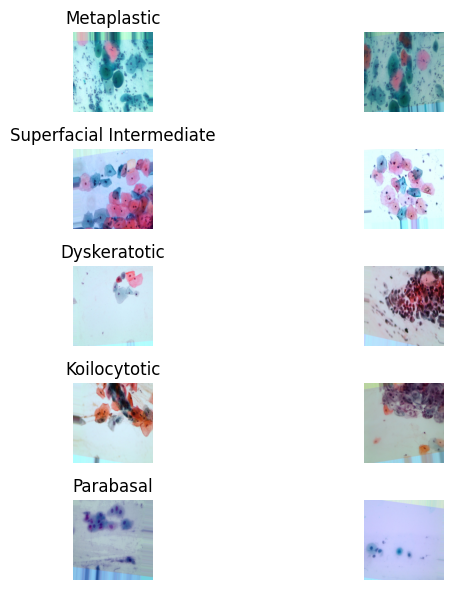

In [ ]:
import os
import matplotlib.image as mpimg

# Define the dataset directory and categories
dataset_dir = dataset_path
categories = ['Metaplastic', 'Superfacial Intermediate', 'Dyskeratotic', 'Koilocytotic', 'Parabasal']

# Number of images to display per category
num_images = 2

# Create a figure with subplots
fig, axes = plt.subplots(len(categories), num_images, figsize=(8, 6))

for i, category in enumerate(categories):
    category_path = os.path.join(dataset_dir, category)
    images = os.listdir(category_path)[:num_images]

    for j, image_name in enumerate(images):
        img_path = os.path.join(category_path, image_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(category.replace('_', ' ').title())

plt.tight_layout()
plt.show()


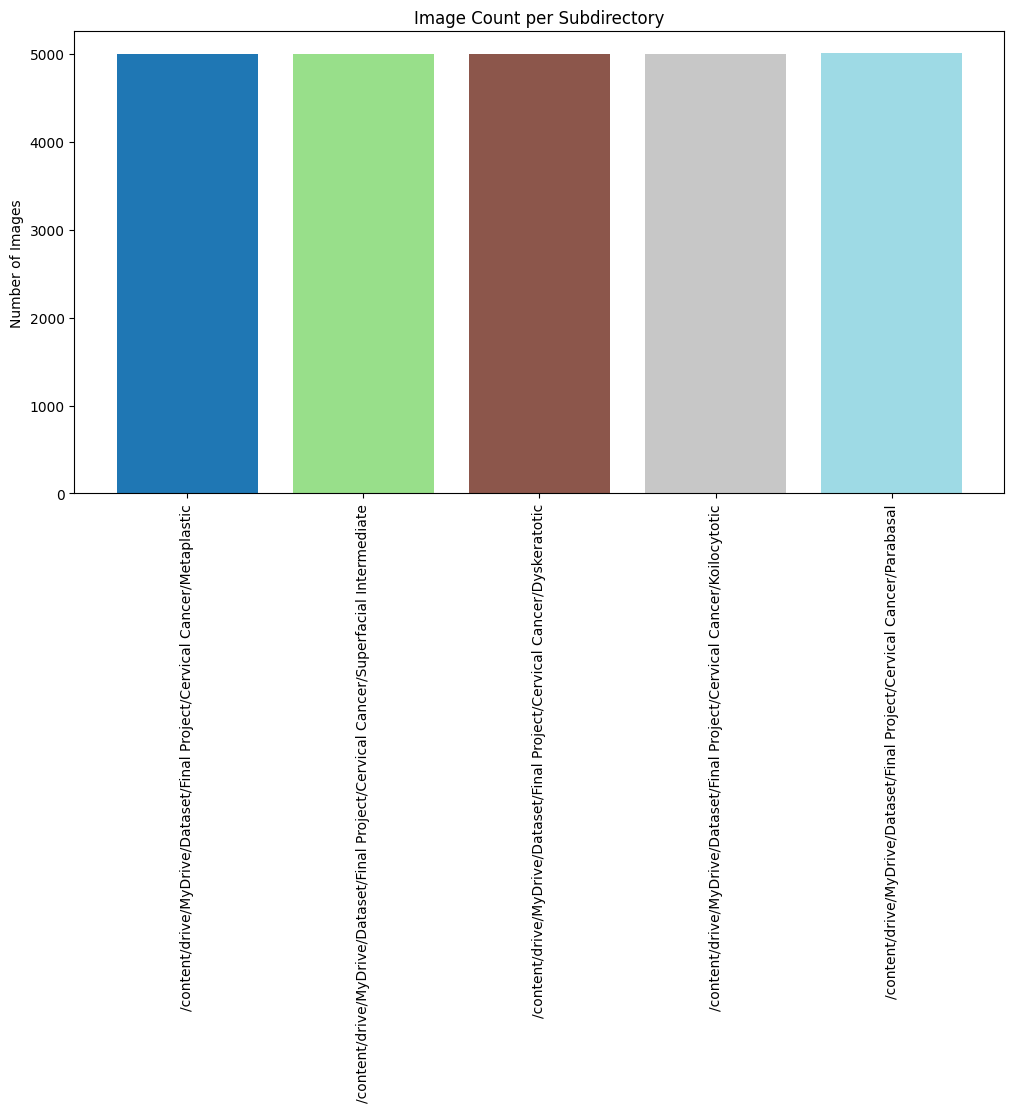

In [ ]:

# Getting subdirectories
subdirectories = [os.path.join(dataset_path, d) for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

counts = [len(os.listdir(directory)) for directory in subdirectories]

colors = plt.cm.get_cmap('tab20', len(subdirectories)).colors

# implementing bar chart with individual colors
plt.figure(figsize=(12, 6))
plt.bar(subdirectories, counts, color=colors)
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Image Count per Subdirectory")
plt.tight_layout()
plt.show()

# Data splitting

In [ ]:
# dataset paths
original_data_dir = dataset_path
base_output_dir = "/content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset"

# ratios for splitting the dataset
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# initializing split directories
splits = ['train', 'val', 'test']
for split in splits:
    for class_name in os.listdir(original_data_dir):
        os.makedirs(os.path.join(base_output_dir, split, class_name), exist_ok=True)

# Shuffling and split images into train/val/test
for class_name in os.listdir(original_data_dir):
    class_dir = os.path.join(original_data_dir, class_name)
    if not os.path.isdir(class_dir):
        continue

    images = os.listdir(class_dir)
    random.shuffle(images)
    total = len(images)

    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]

    for split_name, file_list in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for fname in file_list:
            src = os.path.join(class_dir, fname)
            dst = os.path.join(base_output_dir, split_name, class_name, fname)
            shutil.copyfile(src, dst)

In [ ]:
import hashlib

def checking_duplicates():

  def get_all_image_paths(base_dir):
      image_paths = []
      for root, _, files in os.walk(base_dir):
          for file in files:
              if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                  image_paths.append(os.path.join(root, file))
      return image_paths

  def hash_image(file_path):
      with open(file_path, 'rb') as f:
          return hashlib.md5(f.read()).hexdigest()

  # Paths to your folders
  train_dir = '/content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/train'
  val_dir = '/content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/val'
  test_dir = '/content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/test'

  # Hash images in each split
  train_hashes = {hash_image(path): path for path in get_all_image_paths(train_dir)}
  val_hashes = {hash_image(path): path for path in get_all_image_paths(val_dir)}
  test_hashes = {hash_image(path): path for path in get_all_image_paths(test_dir)}

  # Check for duplicate content (hash match across splits)
  train_val_overlap = set(train_hashes.keys()) & set(val_hashes.keys())
  train_test_overlap = set(train_hashes.keys()) & set(test_hashes.keys())
  val_test_overlap = set(val_hashes.keys()) & set(test_hashes.keys())

  if train_val_overlap or train_test_overlap or val_test_overlap:
      print("Overlap found across splits:")
      if train_val_overlap:
          print(f" - Train ↔ Val: {len(train_val_overlap)} duplicates")
      if train_test_overlap:
          print(f" - Train ↔ Test: {len(train_test_overlap)} duplicates")
      if val_test_overlap:
          print(f" - Val ↔ Test: {len(val_test_overlap)} duplicates")
  else:
      print("No exact image duplicates across train, val, and test splits.")

checking_duplicates()

Overlap found across splits:
 - Train ↔ Val: 4 duplicates
 - Train ↔ Test: 1 duplicates
 - Val ↔ Test: 1 duplicates


In [ ]:
import os
import hashlib
import shutil

# deleting duplicates

base_dir = "/content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset"

splits = ['train', 'val', 'test']

# Compute hash of an image
def hash_image(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Track seen hashes and their original file paths
seen_hashes = {}

# Count of removed files
removed_count = 0

for split in splits:
    print(f"\nScanning {split}/ split...")
    for root, _, files in os.walk(os.path.join(base_dir, split)):
        for fname in files:
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            file_path = os.path.join(root, fname)
            file_hash = hash_image(file_path)

            if file_hash in seen_hashes:
                # Duplicate found, remove it
                os.remove(file_path)
                removed_count += 1
                print(f"Removed duplicate in {split}: {file_path}")
            else:
                # First time this image is seen
                seen_hashes[file_hash] = file_path

print(f"\nDone. Total duplicates removed: {removed_count}")



Scanning train/ split...
Removed duplicate in train: /content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/train/Dyskeratotic/cervix_dyk_4574.jpg
Removed duplicate in train: /content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/train/Dyskeratotic/cervix_dyk_4571 (1).jpg
Removed duplicate in train: /content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/train/Parabasal/cervix_pab_4134.jpg
Removed duplicate in train: /content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/train/Parabasal/cervix_pab_4131 (1).jpg
Removed duplicate in train: /content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/train/Parabasal/cervix_pab_4133.jpg

Scanning val/ split...
Removed duplicate in val: /content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset/val/Dyskeratotic/cervix_dyk_4572 (1).jpg
Removed duplicate in val: /content/drive/MyDrive/Dataset/Final Project/Cervical_c

In [ ]:
checking_duplicates()

No exact image duplicates across train, val, and test splits.


In [ ]:
base_output_dir = "/content/drive/MyDrive/Dataset/Final Project/Cervical_cancer_splitted_dataset"

In [ ]:
# Image augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rotation_range=20
)
val_datagen = ImageDataGenerator(rescale=1.0/255)

train_data = train_datagen.flow_from_directory(
    os.path.join(base_output_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
val_data = val_datagen.flow_from_directory(
    os.path.join(base_output_dir, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


# test data
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_data = test_datagen.flow_from_directory(
    os.path.join(base_output_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle = False
)

Found 17501 images belonging to 5 classes.
Found 3747 images belonging to 5 classes.
Found 3752 images belonging to 5 classes.


In [ ]:
print(test_data.class_indices)

{'Dyskeratotic': 0, 'Koilocytotic': 1, 'Metaplastic': 2, 'Parabasal': 3, 'Superfacial Intermediate': 4}


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np  # Ensure you have this imported

# Getting class indices (e.g., {'cat': 0, 'dog': 1})
class_indices = train_data.class_indices

# Getting the list of class indices in correct order (sorted by index)
class_labels = list(class_indices.values())

# Target labels (integers) from training data
y_train = train_data.classes

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

# Create dictionary: key = class index (int), value = class weight (float)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

class_weight_dict


{np.int32(0): np.float64(1.0000571428571428),
 np.int32(1): np.float64(1.0000571428571428),
 np.int32(2): np.float64(1.0000571428571428),
 np.int32(3): np.float64(0.9997714938588974),
 np.int32(4): np.float64(1.0000571428571428)}

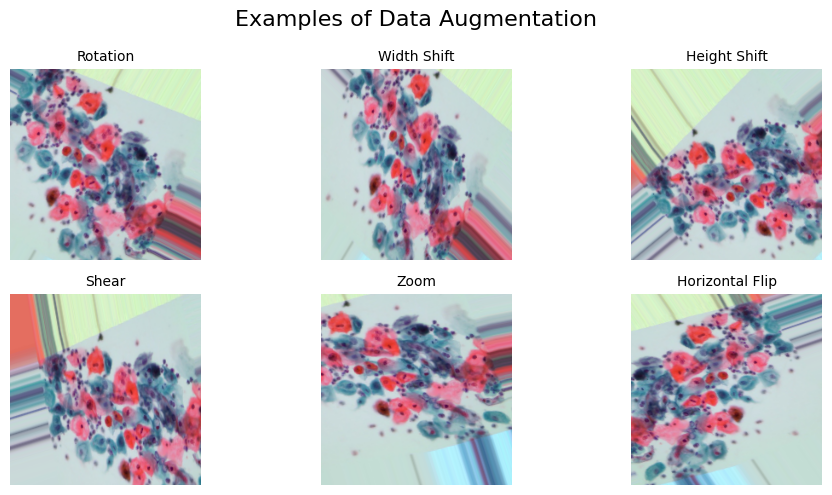

In [ ]:
from tensorflow.keras.preprocessing.image import img_to_array, load_img

#  data augmentation strategy
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Loading and preprocessing an the image
image_path = '/content/drive/MyDrive/Dataset/Final Project/Cervical Cancer/Dyskeratotic/cervix_dyk_0001.jpg'
image = load_img(image_path, target_size=(224, 224))
array_image = img_to_array(image)
array_image = np.expand_dims(array_image, axis=0)


augmented_images = train_datagen.flow(array_image, batch_size=1)


augmentation_style = [
    "Rotation",
    "Width Shift",
    "Height Shift",
    "Shear",
    "Zoom",
    "Horizontal Flip",
]

# Plot augmented images
plt.figure(figsize=(10, 5))
for i in range(6):
    aug_img = next(augmented_images)[0].astype(np.uint8)
    plt.subplot(2, 3, i+1)
    plt.imshow(aug_img)
    plt.axis('off')
    plt.title(f'{augmentation_style[i]}', fontsize=10)
plt.suptitle("Examples of Data Augmentation", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import InceptionV3, MobileNetV2, InceptionResNetV2
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix
from scipy.spatial.distance import euclidean, cityblock, cosine

In [ ]:
# custom cnn
image_height = 224
image_width = 224
model = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(image_height, image_width, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    steps_per_epoch=89,
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1997s 23s/step - accuracy: 0.3359 - loss: 1.8072 - val_accuracy: 0.4257 - val_loss: 1.2395
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 670s 8s/step - accuracy: 0.4330 - loss: 1.2895 - val_accuracy: 0.5775 - val_loss: 0.9751
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 579s 7s/step - accuracy: 0.5905 - loss: 1.0303 - val_accuracy: 0.7264 - val_loss: 0.7832
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 516s 6s/step - accuracy: 0.6501 - loss: 0.8893 - val_accuracy: 0.7406 - val_loss: 0.7606
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 456s 5s/step - accuracy: 0.7038 - loss: 0.7850 - val_accuracy: 0.7422 - val_loss: 0.6647
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.7031 - loss: 0.7351 - val_accuracy: 0.7718 - val_loss: 0.5280
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7471 - loss: 0.7069 - val_accuracy: 0.7988 - val_loss: 0.4946
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 487s 5s/step - accuracy: 0.7701 - loss: 0.6218 - val_accuracy: 0.8137 -

## **Using pre-trained model**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Plot accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', marker='o')
    plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_confusion_matrix(true_labels, predicted_labels, class_names):
    cm = confusion_matrix(true_labels, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(12, 8))
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.xticks(rotation=45, fontsize=10, ha='right')
    plt.yticks(fontsize=10)
    plt.grid(False)
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
def plot_roc_curve(true_labels, predicted_probs, class_names):

    # Binarize the true labels for ROC computation
    true_labels_binarized = label_binarize(true_labels, classes=np.arange(len(class_names)))

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot all ROC curves
    plt.figure(figsize=(10, 7))

    # Individual class ROC curves
    for i, class_name in enumerate(class_names):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve for {class_name} (area = {roc_auc[i]:.2f})')

    # Micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    # Macro-average ROC curve
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'macro-average ROC curve (area = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)

    # Plot settings
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
def evaluate_model(history, true_labels, predicted_labels, class_names, predictions):
    plot_training_history(history)
    plot_confusion_matrix(true_labels, predicted_labels, class_names)
    plot_roc_curve(true_labels, predictions, class_names)

# **MobileNetV2**

In [ ]:
checkpoint = ModelCheckpoint(
    'mobilenet_v2_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
# ===== Building the model =====
def build_model(base_model):
    base_model.trainable = False  # Freezeing pre-trained layers
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(5, activation='softmax')(x)  # 5 classes
    model = Model(inputs, x)
    return model

mobilenet_v2_model = build_model(MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)))
mobilenet_v2_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_mv2 = mobilenet_v2_model.fit(train_data, validation_data=val_data,
                                     epochs=10, callbacks=[checkpoint, early_stopping],
                                     steps_per_epoch=89,
                                    class_weight=class_weight_dict)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6029 - loss: 1.0766
Epoch 1: val_accuracy improved from -inf to 0.86683, saving model to mobilenet_v2_model.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 79s 781ms/step - accuracy: 0.6045 - loss: 1.0725 - val_accuracy: 0.8668 - val_loss: 0.3890
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8534 - loss: 0.4151
Epoch 2: val_accuracy improved from 0.86683 to 0.90019, saving model to mobilenet_v2_model.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 66s 745ms/step - accuracy: 0.8535 - loss: 0.4147 - val_accuracy: 0.9002 - val_loss: 0.2815
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8911 - loss: 0.2904
Epoch 3: val_accuracy did not improve from 0.90019
89/89 ━━━━━━━━━━━━━━━━━━━━ 63s 714ms/step - accuracy: 0.8912 - loss: 0.2904 - val_accuracy: 0.8975 - val_loss: 0.2877
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8990 - loss: 0.2769
Epoch 4: val_accuracy improved from 0.90019 to 0.90846, savi

In [ ]:
test_data.class_indices

{'Dyskeratotic': 0,
 'Koilocytotic': 1,
 'Metaplastic': 2,
 'Parabasal': 3,
 'Superfacial Intermediate': 4}

In [ ]:
# saving the model
mobilenet_v2_model.save('/content/drive/MyDrive/Dataset/Final Project/mobilenet_v2_cervical_model.keras')

In [ ]:
predictions = mobilenet_v2_model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

118/118 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step
Classification Report:
                          precision    recall  f1-score   support

            Dyskeratotic     0.9609    0.9174    0.9387       751
            Koilocytotic     0.9402    0.9227    0.9314       750
             Metaplastic     0.9226    0.9693    0.9454       750
               Parabasal     1.0000    0.9561    0.9775       751
Superfacial Intermediate     0.9445    0.9987    0.9708       750

                accuracy                         0.9528      3752
               macro avg     0.9537    0.9528    0.9528      3752
            weighted avg     0.9537    0.9528    0.9528      3752



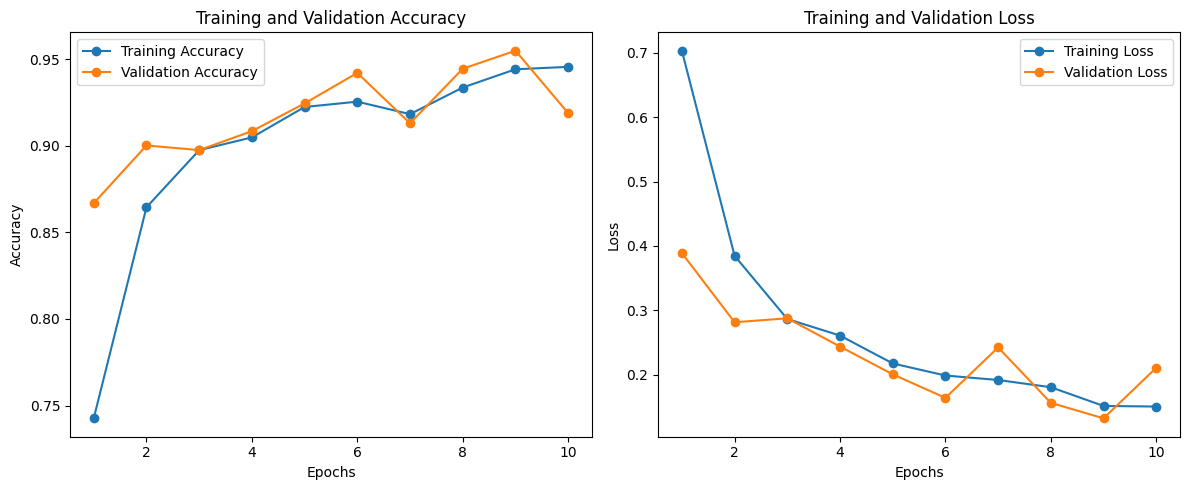

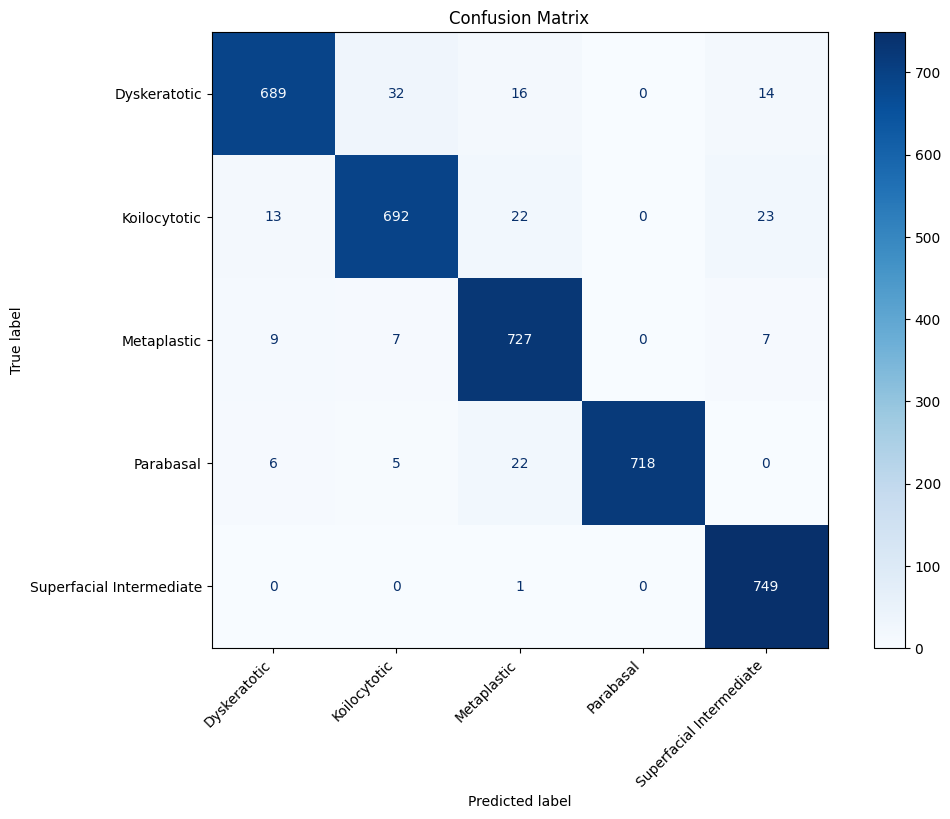

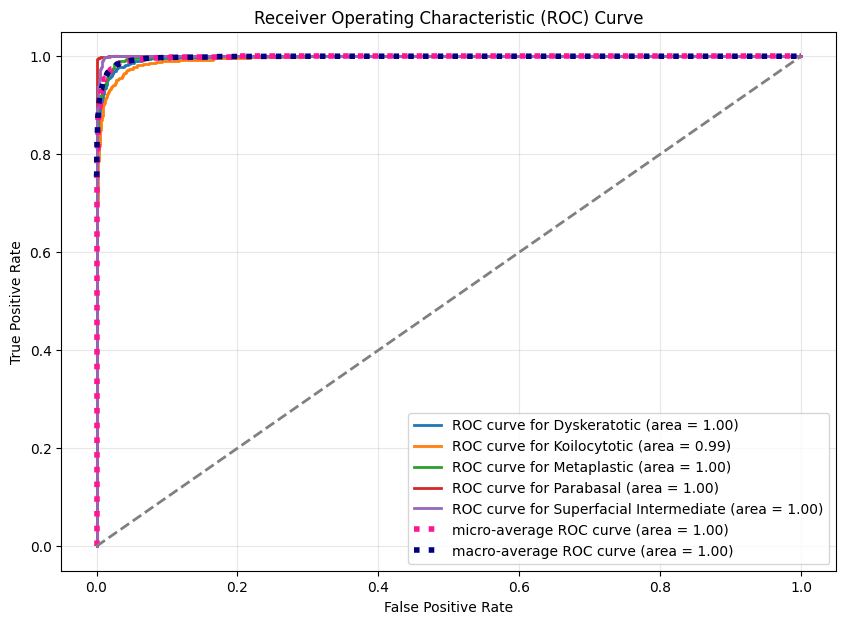

In [ ]:
evaluate_model(history_mv2, true_classes, predicted_classes, class_labels, predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


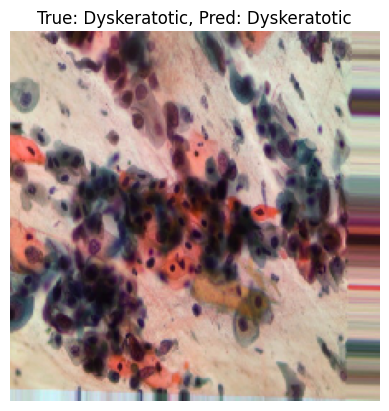

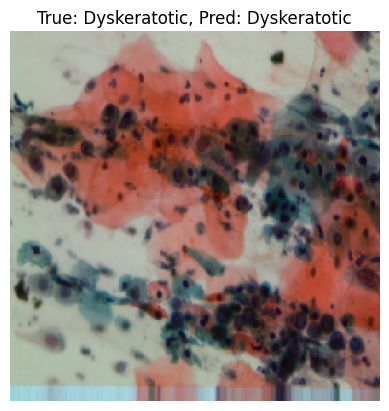

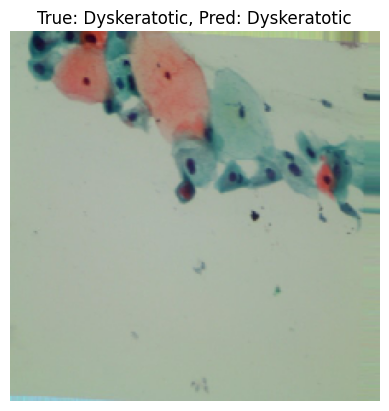

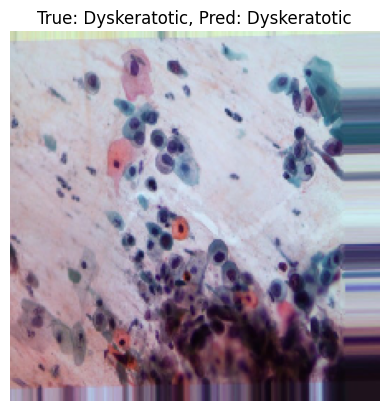

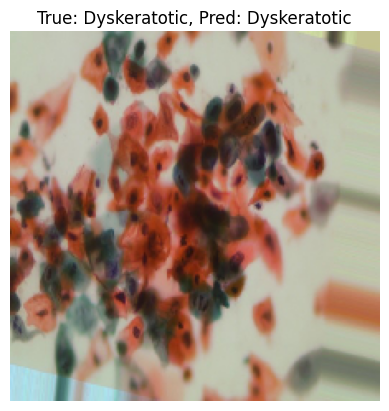

In [ ]:
# Verifying predictions

test_images, test_labels = next(test_data)

batch_predictions = mobilenet_v2_model.predict(test_images)
batch_predicted_classes = np.argmax(batch_predictions, axis=1)

for i in range(5):
    plt.imshow(test_images[i])
    plt.title(f"True: {class_labels[np.argmax(test_labels[i])]}, Pred: {class_labels[batch_predicted_classes[i]]}")
    plt.axis('off')
    plt.show()

**Xception**

In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# Parameters
IMG_SIZE = (224, 224)  # Xception default input size
NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4

# Loading Xception base model
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# Freeze initial layers (optional)
for layer in base_model.layers[:50]:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

xception = Model(inputs=base_model.input, outputs=predictions)

# Compile with lower learning rate for fine-tuning
optimizer = Adam(learning_rate=LEARNING_RATE)
xception.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    ModelCheckpoint(
        'best_xception_spakmed.h5',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

# Train the model
history = xception.fit(
    train_data, validation_data=val_data,
                                     epochs=10, callbacks=callbacks,
                                     steps_per_epoch=89,
                                    class_weight=class_weight_dict
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.5386 - loss: 1.2092

89/89 ━━━━━━━━━━━━━━━━━━━━ 108s 898ms/step - accuracy: 0.5406 - loss: 1.2049 - val_accuracy: 0.8916 - val_loss: 0.3300
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9203 - loss: 0.2569

89/89 ━━━━━━━━━━━━━━━━━━━━ 73s 824ms/step - accuracy: 0.9205 - loss: 0.2564 - val_accuracy: 0.9867 - val_loss: 0.0528
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9653 - loss: 0.1117

89/89 ━━━━━━━━━━━━━━━━━━━━ 75s 848ms/step - accuracy: 0.9654 - loss: 0.1116 - val_accuracy: 0.9915 - val_loss: 0.0248
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9855 - loss: 0.0667

89/89 ━━━━━━━━━━━━━━━━━━━━ 73s 825ms/step - accuracy: 0.9855 - loss: 0.0667 - val_accuracy: 0.9955 - val_loss: 0.0140
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.9829 - loss: 0.0652

89/89 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9829 - loss: 0.0652 - val_accuracy: 0.9973 - val_loss: 0.0104
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.9930 - loss: 0.0329

89/89 ━━━━━━━━━━━━━━━━━━━━ 74s 838ms/step - accuracy: 0.9929 - loss: 0.0329 - val_accuracy: 0.9989 - val_loss: 0.0041
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 28s 312ms/step - accuracy: 0.9904 - loss: 0.0347 - val_accuracy: 0.9957 - val_loss: 0.0111
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9901 - loss: 0.0365

89/89 ━━━━━━━━━━━━━━━━━━━━ 76s 855ms/step - accuracy: 0.9901 - loss: 0.0364 - val_accuracy: 1.0000 - val_loss: 8.0124e-04
Epoch 9/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 75s 850ms/step - accuracy: 0.9913 - loss: 0.0267 - val_accuracy: 0.9997 - val_loss: 9.3504e-04
Epoch 10/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 75s 851ms/step - accuracy: 0.9889 - loss: 0.0416 - val_accuracy: 1.0000 - val_loss: 0.0018


In [ ]:
# saving the model
xception.save('/content/drive/MyDrive/Dataset/Final Project/xception_cervical_cancer.keras')

In [ ]:
predictions = xception.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 250ms/step
Classification Report:
                          precision    recall  f1-score   support

            Dyskeratotic     1.0000    1.0000    1.0000       751
            Koilocytotic     0.9987    1.0000    0.9993       750
             Metaplastic     1.0000    0.9987    0.9993       750
               Parabasal     1.0000    1.0000    1.0000       751
Superfacial Intermediate     1.0000    1.0000    1.0000       750

                accuracy                         0.9997      3752
               macro avg     0.9997    0.9997    0.9997      3752
            weighted avg     0.9997    0.9997    0.9997      3752



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


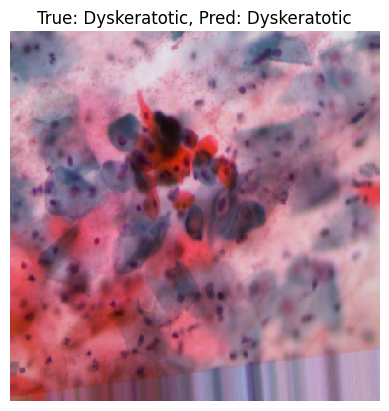

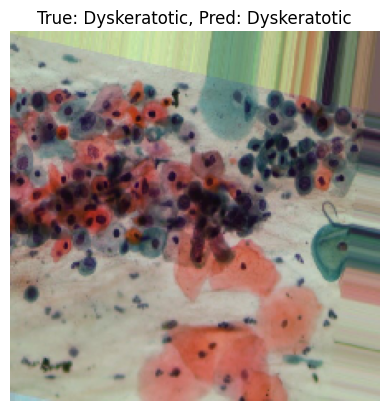

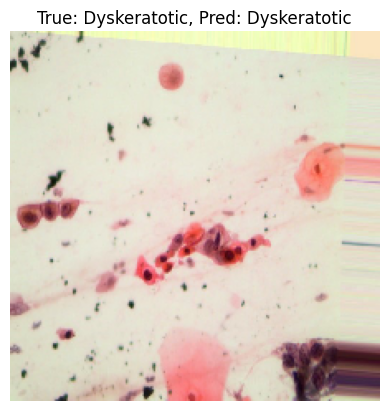

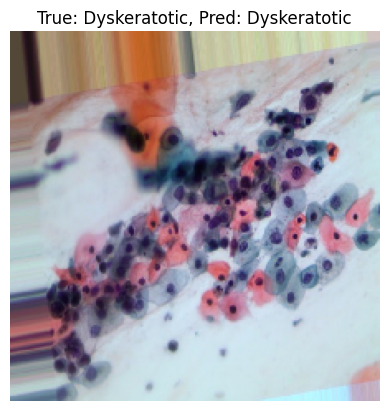

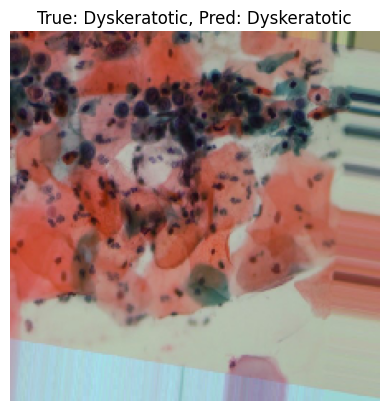

In [ ]:
# Verifying predictions

test_images, test_labels = next(test_data)

batch_predictions = xception.predict(test_images)
batch_predicted_classes = np.argmax(batch_predictions, axis=1)

for i in range(5):
    plt.imshow(test_images[i])
    plt.title(f"True: {class_labels[np.argmax(test_labels[i])]}, Pred: {class_labels[batch_predicted_classes[i]]}")
    plt.axis('off')
    plt.show()

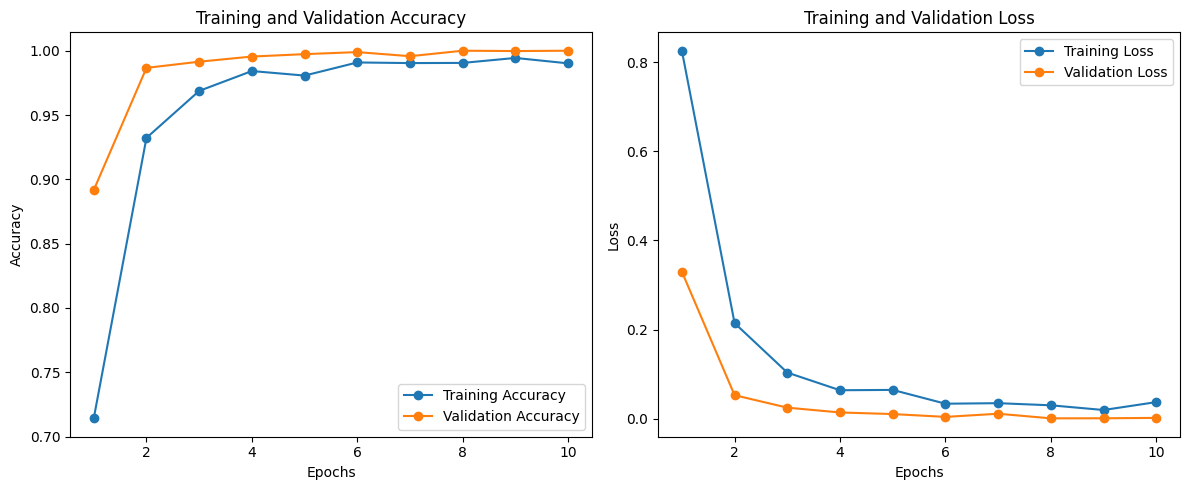

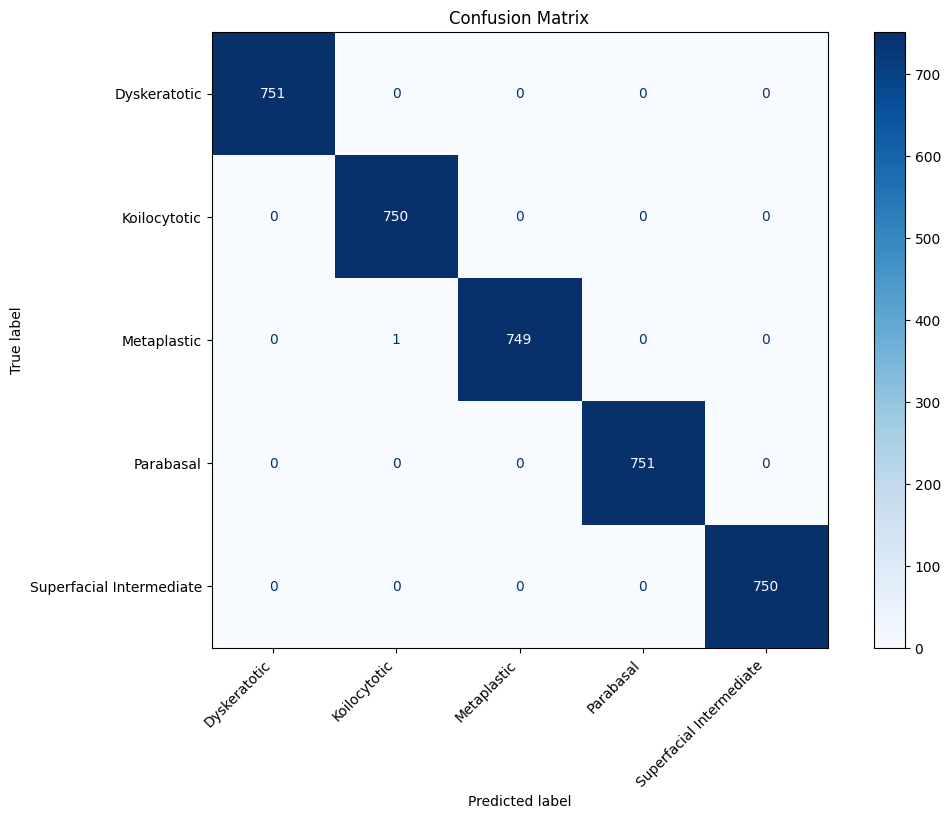

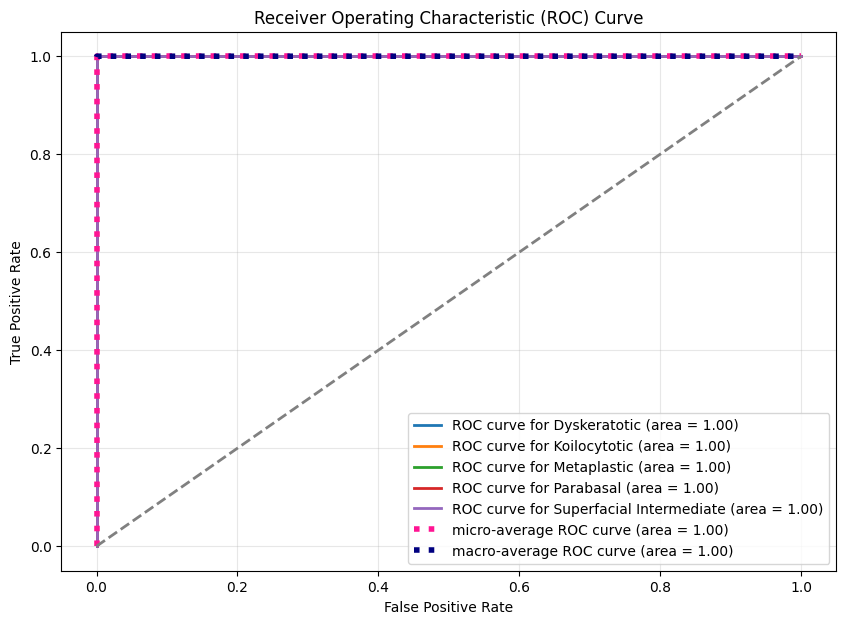

In [ ]:
evaluate_model(history, true_classes, predicted_classes, class_labels, predictions)

In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# Parameters
IMG_SIZE = (224, 224)  # Xception default input size
NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4

# Load Xception base model
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# Freeze initial layers (optional)
for layer in base_model.layers[:50]:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile with lower learning rate for fine-tuning
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    ModelCheckpoint(
        'best_xception_spakmed.h5',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_data, validation_data=val_data,
                                     epochs=15, callbacks=callbacks,
                                     steps_per_epoch=89,
                                    class_weight=class_weight_dict
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5564 - loss: 1.1897 

89/89 ━━━━━━━━━━━━━━━━━━━━ 2585s 29s/step - accuracy: 0.5582 - loss: 1.1858 - val_accuracy: 0.9067 - val_loss: 0.2781
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9107 - loss: 0.2607 

89/89 ━━━━━━━━━━━━━━━━━━━━ 963s 11s/step - accuracy: 0.9109 - loss: 0.2602 - val_accuracy: 0.9685 - val_loss: 0.0930
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9694 - loss: 0.1025

89/89 ━━━━━━━━━━━━━━━━━━━━ 814s 9s/step - accuracy: 0.9695 - loss: 0.1025 - val_accuracy: 0.9939 - val_loss: 0.0261
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 690s 8s/step - accuracy: 0.9777 - loss: 0.0719 - val_accuracy: 0.9933 - val_loss: 0.0174
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 600s 7s/step - accuracy: 0.9849 - loss: 0.0463 - val_accuracy: 0.9925 - val_loss: 0.0250
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9814 - loss: 0.0542

89/89 ━━━━━━━━━━━━━━━━━━━━ 559s 6s/step - accuracy: 0.9814 - loss: 0.0541 - val_accuracy: 0.9971 - val_loss: 0.0092
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 62s 699ms/step - accuracy: 0.9849 - loss: 0.0418 - val_accuracy: 0.9939 - val_loss: 0.0133
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 445s 5s/step - accuracy: 0.9955 - loss: 0.0221 - val_accuracy: 0.9960 - val_loss: 0.0106
Epoch 9/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9932 - loss: 0.0224

89/89 ━━━━━━━━━━━━━━━━━━━━ 387s 4s/step - accuracy: 0.9932 - loss: 0.0224 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 10/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9925 - loss: 0.0386

89/89 ━━━━━━━━━━━━━━━━━━━━ 314s 4s/step - accuracy: 0.9925 - loss: 0.0384 - val_accuracy: 0.9997 - val_loss: 7.3285e-04
Epoch 11/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9905 - loss: 0.0250

89/89 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.9906 - loss: 0.0250 - val_accuracy: 1.0000 - val_loss: 4.1104e-04
Epoch 12/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9965 - loss: 0.0097 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 13/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9961 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 4.9233e-04
Epoch 14/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 29s 321ms/step - accuracy: 0.9954 - loss: 0.0147 - val_accuracy: 0.9997 - val_loss: 8.2373e-04


In [ ]:
# saving the model
model.save('/content/drive/MyDrive/Dataset/Final Project/xception_cervical_cancer.keras')

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/Dataset/Final Project/xception_cervical_cancer.keras')

In [ ]:
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step
Classification Report:
                          precision    recall  f1-score   support

            Dyskeratotic     1.0000    0.9947    0.9973       752
            Koilocytotic     0.9960    0.9987    0.9973       750
             Metaplastic     0.9934    0.9973    0.9953       750
               Parabasal     1.0000    0.9987    0.9993       752
Superfacial Intermediate     0.9987    0.9987    0.9987       750

                accuracy                         0.9976      3754
               macro avg     0.9976    0.9976    0.9976      3754
            weighted avg     0.9976    0.9976    0.9976      3754



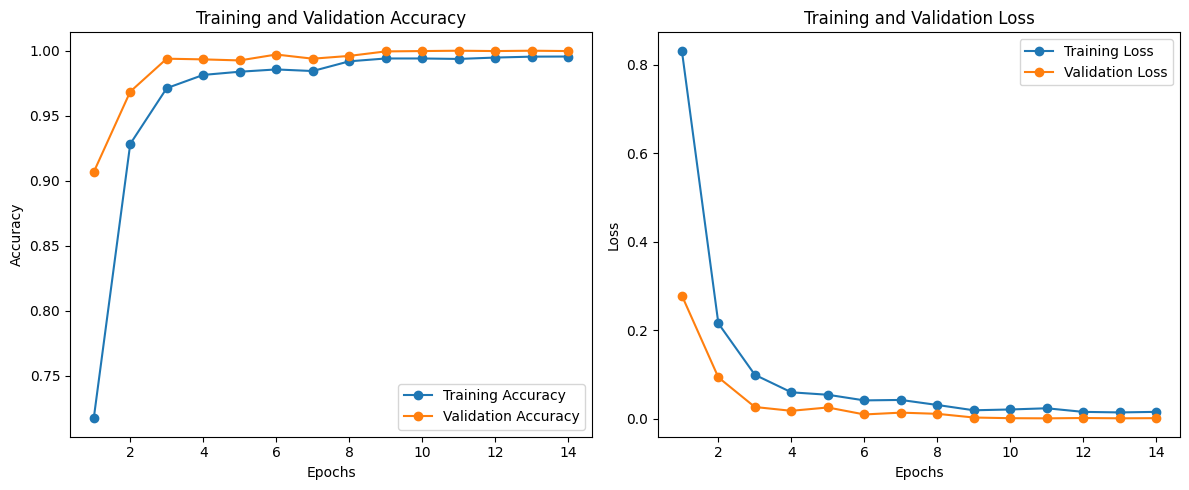

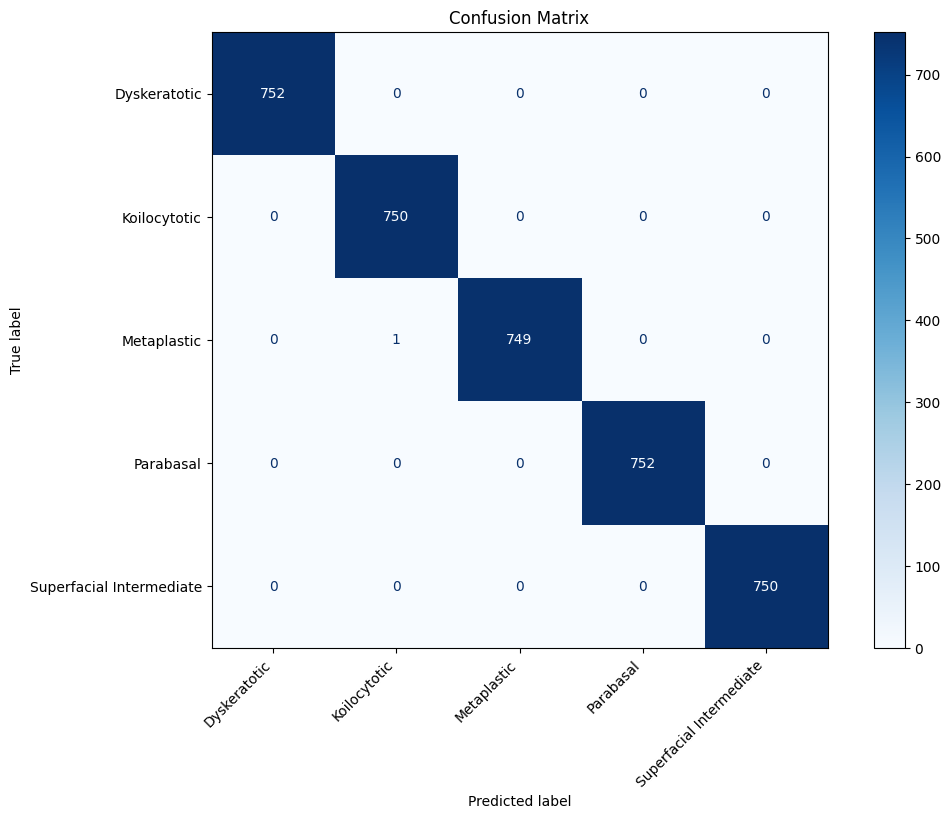

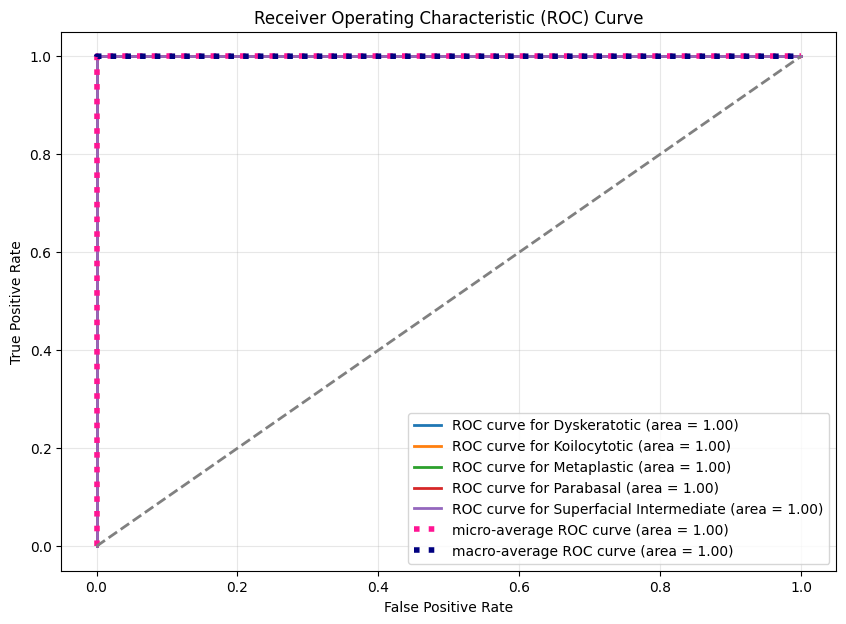

In [ ]:
evaluate_model(history, true_classes, predicted_classes, class_labels, predictions)

# inceptionv3

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# 3. Load Pretrained InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 4. Freeze First 100 Layers
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True

# 5. Add Custom Top Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

inceptionV3_model = Model(inputs=base_model.input, outputs=predictions)

# 6. Compile Model
inceptionV3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Callbacks: Early Stopping and Model Checkpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_inceptionv3_cervical_spakmed_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 8. Training the Model
inception_history = inceptionV3_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    steps_per_epoch=89,
    class_weight=class_weight_dict
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 138s 915ms/step - accuracy: 0.5469 - loss: 1.1048 - val_accuracy: 0.8855 - val_loss: 0.3502
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9157 - loss: 0.2285 - val_accuracy: 0.9549 - val_loss: 0.1205
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 65s 732ms/step - accuracy: 0.9609 - loss: 0.1227 - val_accuracy: 0.9680 - val_loss: 0.1116
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 66s 753ms/step - accuracy: 0.9708 - loss: 0.0891 - val_accuracy: 0.9917 - val_loss: 0.0303
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 66s 748ms/step - accuracy: 0.9868 - loss: 0.0566 - val_accuracy: 0.9981 - val_loss: 0.0085
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 65s 738ms/step - accuracy: 0.9824 - loss: 0.0479 - val_accuracy: 0.9973 - val_loss: 0.0096
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 252ms/step - accuracy: 0.9979 - loss: 0.0202 - val_accuracy: 0.9939 - val_loss: 0.0162
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 68s 766ms/step - accuracy: 0.9816 - loss: 0.0660 - val_accura

In [ ]:
# saving the model
inceptionV3_model.save('/content/drive/MyDrive/Dataset/Final Project/inception_cervical_model.keras')

In [ ]:
predictions = inceptionV3_model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 274ms/step
Classification Report:
                          precision    recall  f1-score   support

            Dyskeratotic     1.0000    0.9933    0.9967       751
            Koilocytotic     0.9934    0.9973    0.9953       750
             Metaplastic     0.9973    1.0000    0.9987       750
               Parabasal     1.0000    1.0000    1.0000       751
Superfacial Intermediate     1.0000    1.0000    1.0000       750

                accuracy                         0.9981      3752
               macro avg     0.9981    0.9981    0.9981      3752
            weighted avg     0.9981    0.9981    0.9981      3752



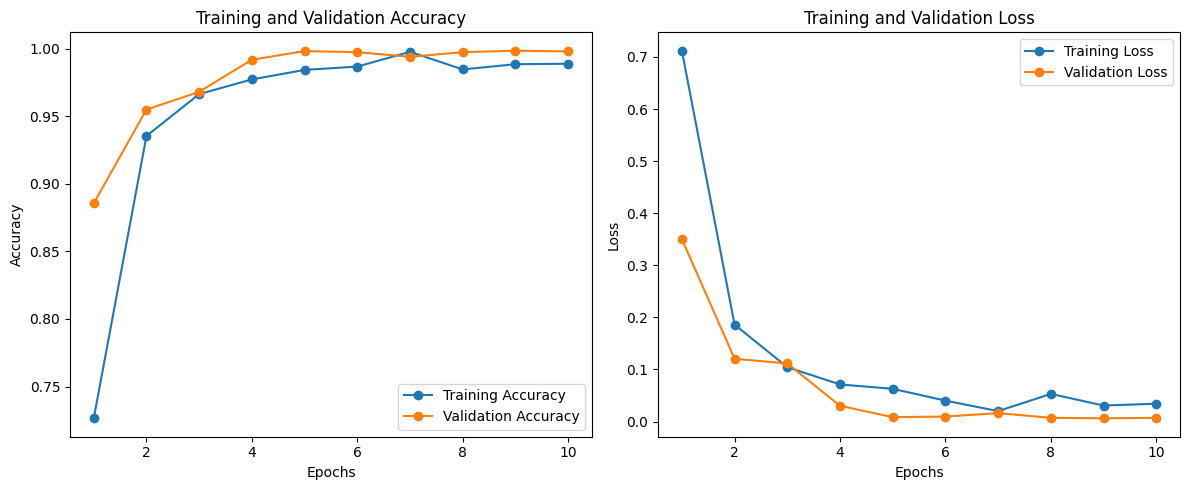

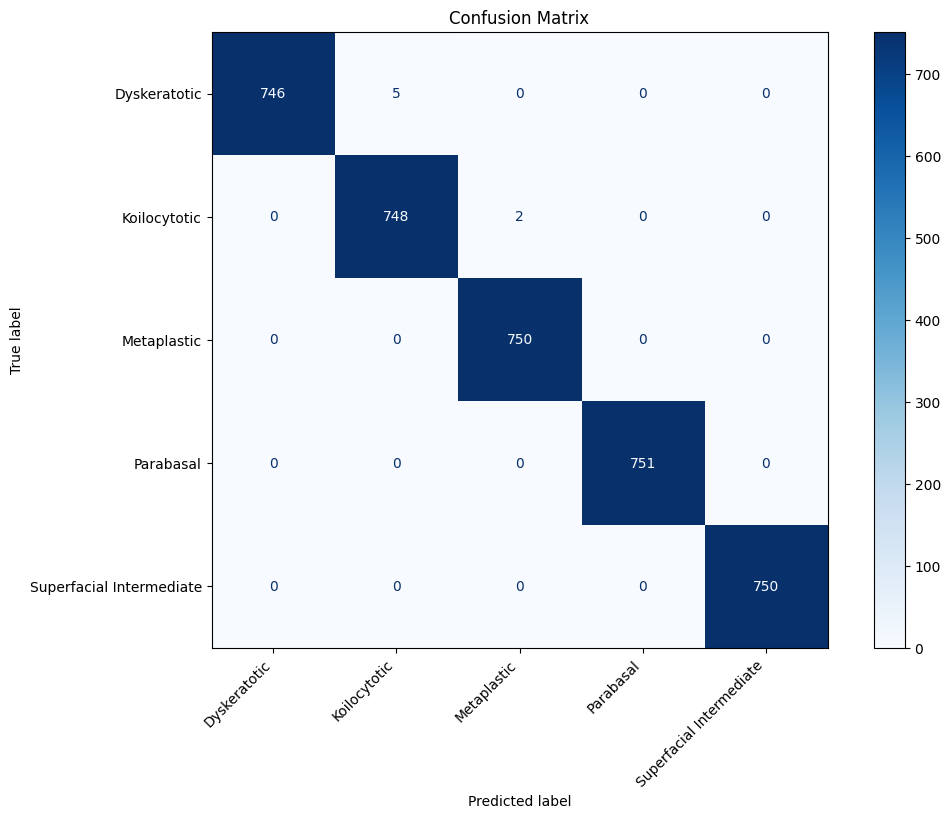

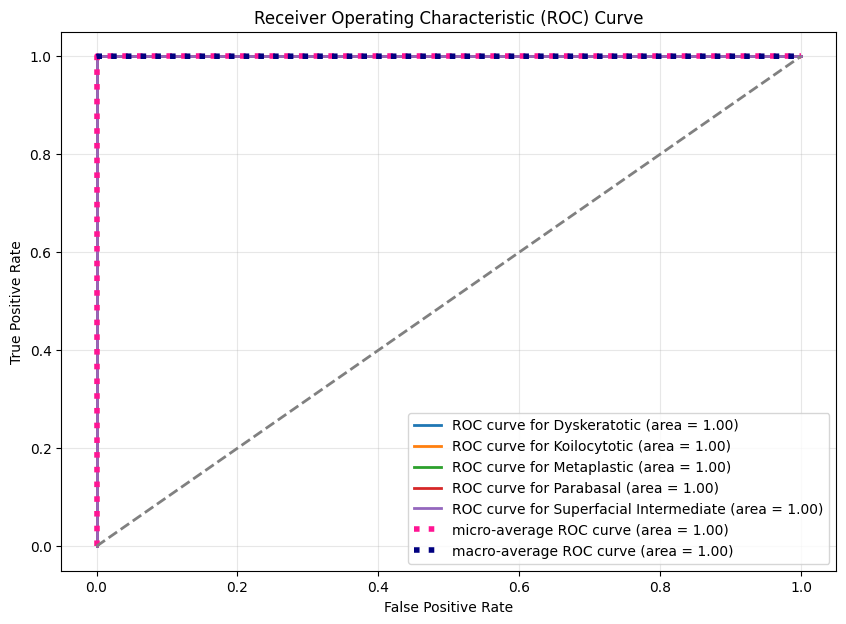

In [ ]:
evaluate_model(inception_history, true_classes, predicted_classes, class_labels, predictions)